# 10 — First-visit yearly re-eligibility

One row per client with their most recent completed first-visit payment, and days remaining until they may pay for another first visit under the 365-day rule. Mirrors `checkFirstVisitYearlyEligibility` and `docs/Client_Querires.md` §2.3.

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_ANALYST_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
WITH last_first_visit AS (
  SELECT
    user_id,
    MAX(payment_date) AS last_first_visit_paid_at
  FROM client_payments
  WHERE visit_type = '1'
    AND visit_paid = 1
    AND payment_status = 'completed'
  GROUP BY user_id
)
SELECT
  u.id AS client_id,
  u.name,
  u.surname,
  l.last_first_visit_paid_at,
  DATEDIFF(CURRENT_DATE, l.last_first_visit_paid_at) AS days_since_first_visit,
  GREATEST(365 - DATEDIFF(CURRENT_DATE, l.last_first_visit_paid_at), 0) AS days_until_eligible,
  DATEDIFF(CURRENT_DATE, l.last_first_visit_paid_at) >= 365 AS can_pay_first_visit
FROM users u
JOIN last_first_visit l ON l.user_id = u.id
WHERE u.role_id = 6
ORDER BY days_until_eligible DESC;
"""

df = pd.read_sql(query, engine, parse_dates=["last_first_visit_paid_at"])
print(df)

    client_id                 name   surname last_first_visit_paid_at  \
0         131           testHidden       mac      2026-07-10 10:11:00   
1         129       proTranslation     local      2026-07-07 09:41:40   
2         127   localErrorrTrigger   task279      2026-05-28 07:09:35   
3         126          LForceCheck       Pro      2026-05-22 09:07:34   
4         125        LFibroMissing       Pro      2026-05-22 08:54:46   
5         124               LOrder       Pro      2026-05-22 08:42:06   
6         123            LSeverity       pro      2026-05-20 09:20:52   
7         122         paymentLocal       Pro      2026-05-08 08:06:58   
8         121      fibromialgiaPro       mac      2026-05-05 14:41:37   
9         120             EltomPro      John      2026-05-04 12:59:38   
10        119              cypress    macPro      2026-04-14 06:04:57   
11        115  Test_03.04.26.12.41      User      2026-04-03 09:41:51   
12        116             localPro  weight20      2

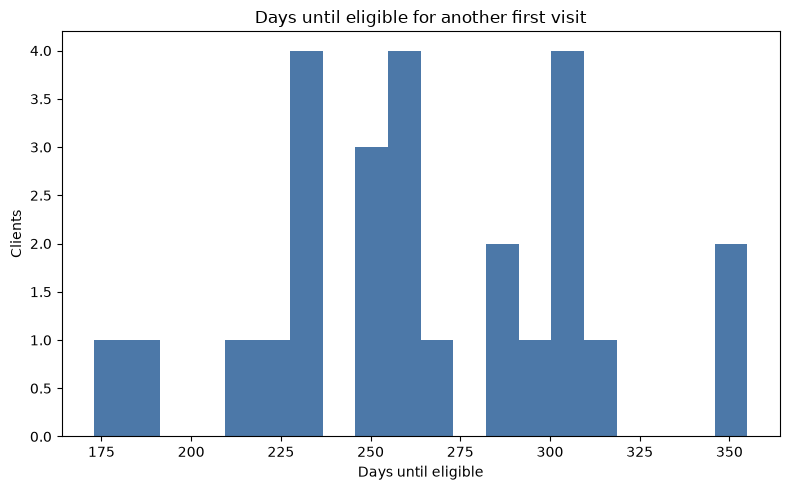

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

if df.empty:
    print("No first-visit payment data found.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df["days_until_eligible"], bins=20, color="#4C78A8")
    ax.set_title("Days until eligible for another first visit")
    ax.set_xlabel("Days until eligible")
    ax.set_ylabel("Clients")
    fig.tight_layout()

    os.makedirs("../assets/img", exist_ok=True)
    fig.savefig("../assets/img/first_visit_yearly_eligibility.png", dpi=150)
    plt.show()